In [18]:
import os 
import re
import time
import torch
import pathlib 
import numpy as np
import pandas as pd
from math import ceil
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, random_split

from basic_cnn import*

In [2]:
# emb1 = torch.load('/Users/racheliritani/Desktop/neurovfm/output/emdeddings/sub-105046731194_encoder_embeddings.pt')
# emb2 = torch.load('/Users/racheliritani/Desktop/neurovfm/output/emdeddings/sub-388018649913_encoder_embeddings.pt')
subject_meta = pd.read_csv('/Users/racheliritani/Desktop/neurovfm/output/participants.tsv', sep='\t')
#output_dir = '/Users/racheliritani/Desktop/neurovfm/output/embeddings/'
output_dir = '/Users/racheliritani/Desktop/neurovfm/output/embeddings_sub/'

In [3]:
max_dim0 = 0
max_dim1 = 0
file_shapes = {}
for file in os.listdir(output_dir):
    if file.endswith(".pt"):
        path = os.path.join(output_dir, file)
        emb = torch.load(path)
    if isinstance(emb, torch.Tensor):
        shape = emb.shape
    else:
        shape = emb["embedding"].shape
        file_shapes[file] = shape
    if len(shape) >= 2:
        max_dim0 = max(max_dim0, shape[0])
        max_dim1 = max(max_dim1, shape[1])
    elif len(shape) == 1:
        max_dim0 = max(max_dim0, shape[0])
print("Shapes per file:")
for f, s in file_shapes.items():
    print(f"{f}: {s}")
    print("\nMaximum dimensions across all embeddings:")
    print("max_dim0:", max_dim0)
    print("max_dim1:", max_dim1)

Shapes per file:


In [4]:
max_h = max_dim0
max_w = max_dim1
def round_up(x, base=16):
    return int(base * ceil(x / base))
pad_h = round_up(max_h, 16)
pad_w = round_up(max_w, 16)
print("Padded target shape:", pad_h, pad_w)

Padded target shape: 800 768


In [5]:
output_folder = "/Users/racheliritani/Desktop/neurovfm/output/padded_embeddings_sub/"
os.makedirs(output_folder, exist_ok=True)
for file in os.listdir(output_dir):
    if file.endswith(".pt"):
        path = os.path.join(output_dir, file)
        emb = torch.load(path)
    if isinstance(emb, dict):
        emb = emb["embedding"]
    h, w = emb.shape
    pad_bottom = pad_h - h
    pad_right = pad_w - w
    padded = F.pad(
    emb,
    (0, pad_right, 0, pad_bottom),
    mode="constant",
    value=0
    )
    save_path = os.path.join(output_folder, file)
    torch.save(padded, save_path)

In [6]:
sum_ = 0.0
sq_sum = 0.0
count = 0
for f in os.listdir(output_folder):
    if f.endswith(".pt"):
        x = torch.load(os.path.join(output_folder, f)).float()
        sum_ += x.sum().item()
        sq_sum += (x**2).sum().item()
        count += x.numel()
mean = sum_ / count
std = ((sq_sum / count) - mean ** 2) ** 0.5
print("mean:", mean)
print("std:", std)

mean: -0.00334273160923095
std: 0.05780219486696182


In [7]:
path = pathlib.Path(output_folder)
data_list = []

filename_pattern = re.compile(r'sub-([^_]+)')
for file in path.glob('*.pt'):
    match = filename_pattern.search(file.name)
    subj_id = match.group(1)
    emb_tensor = torch.load(file, map_location='cpu')

    emb_tensor_np = emb_tensor.detach().cpu()
    data_list.append({
        'subject id': subj_id, 
        'embedding': emb_tensor_np
    })

In [8]:
emb_df = pd.DataFrame(data_list)
subject_meta['participant_id'] =  subject_meta['participant_id'].astype(str)
age_embedding_df = pd.merge(emb_df, subject_meta, left_on='subject id', right_on='participant_id', how='inner')

In [9]:
age_embedding_df

,subject id,embedding,participant_id,study,sex,age,site,diagnosis,tiv,csfv,gmv,wmv,magnetic_field_strength,acquisition_setting,split
0,140105537115,"[[tensor(0.0002), tensor(0.0377), tensor(-0.00...",140105537115,2,female,5.907000,41.0,control,1428.085157,119.468494,833.394867,474.034831,3.0,1.0,external_test
1,114301578470,"[[tensor(-0.0003), tensor(0.0367), tensor(0.00...",114301578470,8,male,21.666667,55.0,control,1444.444276,208.102823,711.257245,524.330864,3.0,1.0,external_test
2,107989352584,"[[tensor(-0.0027), tensor(0.0384), tensor(0.00...",107989352584,8,female,38.000000,48.0,control,1234.336318,205.397075,595.299439,433.157145,3.0,1.0,internal_test
3,108597937741,"[[tensor(0.0026), tensor(0.0398), tensor(0.007...",108597937741,8,female,21.000000,55.0,control,1391.362106,220.964697,696.715656,473.118452,3.0,1.0,external_test
4,105819777108,"[[tensor(-0.0025), tensor(0.0395), tensor(0.01...",105819777108,8,female,26.000000,55.0,control,1253.838945,200.619335,600.753825,451.455871,3.0,1.0,external_test
5,136803655621,"[[tensor(-0.0010), tensor(0.0369), tensor(0.00...",136803655621,1,male,19.130000,41.0,control,1412.647396,251.428400,658.976278,501.842310,3.0,1.0,external_test
6,135174484625,"[[tensor(0.0011), tensor(0.0432), tensor(0.006...",135174484625,8,female,21.000000,55.0,control,1439.201346,269.850590,648.972409,519.979634,3.0,1.0,external_test
7,110893004866,"[[tensor(-0.0016), tensor(0.0417), tensor(0.00...",110893004866,8,female,20.000000,55.0,control,1597.332296,295.015329,767.256448,534.598346,3.0,1.0,external_test
8,138580586238,"[[tensor(-0.0003), tensor(0.0367), tensor(0.00...",138580586238,8,female,28.000000,55.0,control,1533.126166,284.829567,709.270929,538.133435,3.0,1.0,external_test
9,138967708043,"[[tensor(-0.0103), tensor(0.0353), tensor(0.00...",138967708043,1,male,22.000000,31.0,control,1501.833966,302.957453,664.278783,534.264705,3.0,1.0,internal_test


In [10]:
class MRIDataset(Dataset):
    def __init__(self, df, mean=None, std=None):
        self.df = df
        self.data = self.df['embedding']
        self.mean = mean
        self.std = std
        self.age = self.df['age']
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        x = (self.data[idx] - self.mean) / (self.std + 1e-8)
        x = x.unsqueeze(0)
        y = self.age[idx]
        return x, y

In [11]:
random_seed = 42
dataset = MRIDataset(age_embedding_df, mean = mean, std=std)
train_size = int(0.70 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, test_size, val_size], generator=torch.Generator().manual_seed(random_seed))

In [12]:
print(len(train_dataset), len(val_dataset), len(test_dataset)) # for reference

9 3 2


In [13]:
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = 32, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 32, shuffle = True)

In [14]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
model = RegCNN(input_height=pad_h, input_width=pad_w).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
print(f'Model initialize on {device}')

Model initialize on mps


In [15]:
def train(model, train_loader, val_loader, epochs=10):
    train_losses = []
    val_losses = []
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        for emb, age in train_loader:
            emb, age = emb.to(device, dtype=torch.float32), age.to(device, dtype=torch.float32)

            optimizer.zero_grad()
            outputs = model(emb).squeeze()
            loss = criterion(outputs, age)

            loss.backward()
            optimizer.step()

            train_loss += loss.item() * emb.size(0)
        
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for emb, age in val_loader:
                emb, age = emb.to(device, dtype=torch.float32), age.to(device, dtype=torch.float32)

                outputs = model(emb).squeeze()
                loss = criterion(outputs, age)
                val_loss += loss.item() * emb.size(0)
        
        avg_train_loss = train_loss / len(train_loader.dataset)
        train_losses.append(avg_train_loss)
        avg_val_loss = val_loss / len(val_loader.dataset)
        val_losses.append(avg_val_loss)


        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    
    return train_losses, val_losses

In [20]:
start_time = time.time()
train_losses, val_losses = train(model, train_loader, val_loader)
end_time = time.time()
total_time = end_time - start_time
print(f" Training Complete!")
print(f"Total time: {int(total_time // 60)}m {int(total_time % 60)}s")

Epoch [1/10] | Train Loss: 174.9435 | Val Loss: 139.6055
Epoch [2/10] | Train Loss: 45.9735 | Val Loss: 61.0349
Epoch [3/10] | Train Loss: 134.4706 | Val Loss: 58.9054
Epoch [4/10] | Train Loss: 126.2349 | Val Loss: 113.7484
Epoch [5/10] | Train Loss: 41.1831 | Val Loss: 327.6173
Epoch [6/10] | Train Loss: 131.4777 | Val Loss: 228.5805
Epoch [7/10] | Train Loss: 79.1271 | Val Loss: 74.7564
Epoch [8/10] | Train Loss: 46.5103 | Val Loss: 53.7975
Epoch [9/10] | Train Loss: 96.9175 | Val Loss: 54.0133
Epoch [10/10] | Train Loss: 81.2756 | Val Loss: 90.2595
 Training Complete!
Total time: 0m 2s


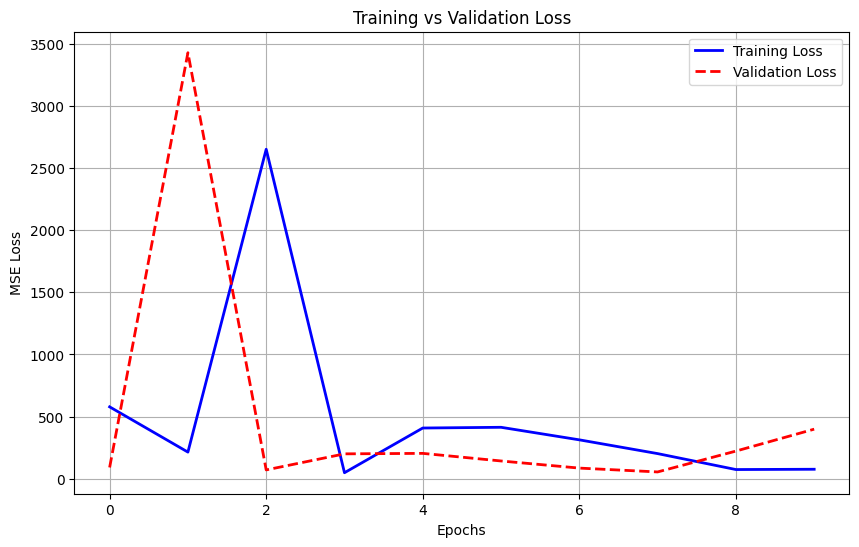

In [17]:
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss', color='blue', lw=2)
plt.plot(val_losses, label='Validation Loss', color='red', lw=2, linestyle='--')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()